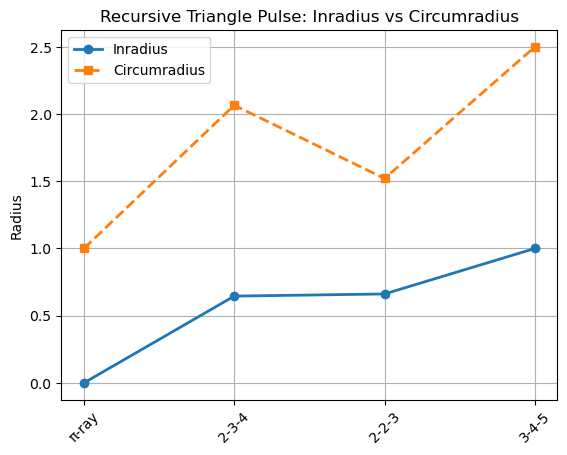

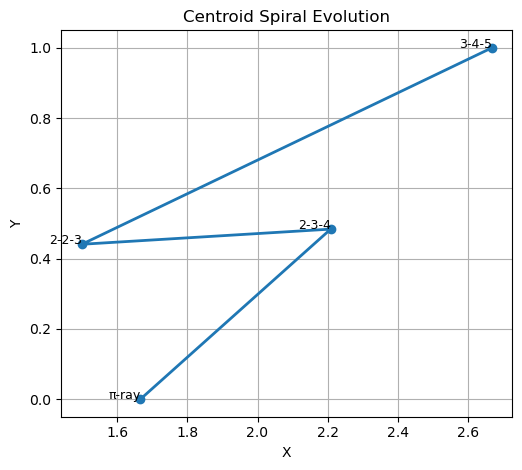

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Triangle data: (label, A, B, C, inradius r, circumradius R, centroid (Gx, Gy))
triangles = [
    ("π-ray", np.array([0, 0]), np.array([4, 0]), np.array([1, 0]), 0.0, 1.0, (1.6667, 0.0)),
    ("2-3-4", np.array([0, 0]), np.array([4, 0]), np.array([2.625, 1.45237]), 0.6455, 2.06559, (2.20833, 0.48412)),
    ("2-2-3", np.array([0, 0]), np.array([3, 0]), np.array([1.5, 1.32288]), 0.66144, 1.52059, (1.5, 0.44096)),
    ("3-4-5", np.array([0, 0]), np.array([4, 0]), np.array([4, 3]), 1.0, 2.5, (2.6667, 1.0))
]

# Extract data for plots
labels = []
inradii = []
circumradii = []
centroids_x = []
centroids_y = []

for label, A, B, C, r, R, G in triangles:
    labels.append(label)
    inradii.append(r)
    circumradii.append(R)
    centroids_x.append(G[0])
    centroids_y.append(G[1])

# Plot 1: Inradius and Circumradius over Triangle Sequence
fig1, ax1 = plt.subplots()
x_vals = np.arange(len(triangles))
ax1.plot(x_vals, inradii, 'o-', label='Inradius', linewidth=2)
ax1.plot(x_vals, circumradii, 's--', label='Circumradius', linewidth=2)
ax1.set_title("Recursive Triangle Pulse: Inradius vs Circumradius")
ax1.set_xticks(x_vals)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel("Radius")
ax1.legend()
ax1.grid(True)

# Plot 2: Centroid Spiral Path
fig2, ax2 = plt.subplots()
ax2.plot(centroids_x, centroids_y, 'o-', linewidth=2)
for i, label in enumerate(labels):
    ax2.text(centroids_x[i], centroids_y[i], label, fontsize=9, ha='right')
ax2.set_title("Centroid Spiral Evolution")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


In [2]:
# %matplotlib notebook # Comment this out - we will use a different display method
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import matplotlib.animation as animation # Ensure animation is imported

# Import HTML display utility from IPython
from IPython.display import HTML

# Triangle 1 (Pi-Ray degenerate triangle): All points on a straight line
A1 = np.array([0, 0])
B1 = np.array([4, 0])
C1 = np.array([1, 0]) # Linear collapse triangle (degenerate)

# Triangle 2 (Emergent triangle from 2, 3, 4 sides)
A2 = np.array([0, 0])
B2 = np.array([4, 0])
C2 = np.array([2.625, 1.45237]) # As per triangle calculator output

# Animation setup
frames = 60
points_A = np.linspace(A1, A2, frames)
points_B = np.linspace(B1, B2, frames) # B point is static as B1=B2
points_C = np.linspace(C1, C2, frames)

# Set up plot
fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot([], [], 'o-', lw=2, color='blue')
ax.set_xlim(-1, 5.5)
ax.set_ylim(-1, 3)
ax.set_aspect('equal')
ax.set_title('Recursive Harmonic Triangle Transition\n(π-Ray → Emergent 2-3-4 Triangle)')
ax.grid(True)

# Close the figure to prevent it from being displayed as a static plot before the animation
plt.close(fig)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Update function
def update(frame):
    A = points_A[frame]
    B = points_B[frame]
    C = points_C[frame]
    x = [A[0], B[0], C[0], A[0]]
    y = [A[1], B[1], C[1], A[1]]
    line.set_data(x, y)
    return line,

# Run animation
# Need to ensure a writer like 'ffmpeg' or 'imagemagick' is available or use the html5 backend
# Use the HTML5 backend, which requires no external writers but relies on browser capabilities
ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=50)

# Show the animation using HTML5 video
# This method generates HTML for an HMTL5 video tag
# HTML(ani.to_jshtml()) # Alternative using JS, might still hit IPython if JS is the issue
HTML(ani.to_html5_video()) # Renders as HTML5 video tag

# plt.show() # This is no longer needed with the HTML display method

In [1]:
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Triangle data: (label, A, B, C, inradius r, circumradius R, centroid G)
triangles = [
    ("π-ray", np.array([0, 0]), np.array([4, 0]), np.array([1, 0]), 0.0, 1.0, (1.6667, 0.0)),
    ("2-3-4", np.array([0, 0]), np.array([4, 0]), np.array([2.625, 1.45237]), 0.6455, 2.06559, (2.20833, 0.48412)),
    ("2-2-3", np.array([0, 0]), np.array([3, 0]), np.array([1.5, 1.32288]), 0.66144, 1.52059, (1.5, 0.44096)),
    ("3-4-5", np.array([0, 0]), np.array([4, 0]), np.array([4, 3]), 1.0, 2.5, (2.6667, 1.0))
]

# Extract sequences
labels = []
inradii = []
circumradii = []
centroids_x = []
centroids_y = []

for label, A, B, C, r, R, G in triangles:
    labels.append(label)
    inradii.append(r)
    circumradii.append(R)
    centroids_x.append(G[0])
    centroids_y.append(G[1])

# --- Plot 1: Inradius vs Circumradius Pulse ---
fig1, ax1 = plt.subplots()
x_vals = np.arange(len(triangles))
ax1.plot(x_vals, inradii, 'o-', label='Inradius', linewidth=2)
ax1.plot(x_vals, circumradii, 's--', label='Circumradius', linewidth=2)
ax1.set_title("Recursive Triangle Pulse: Inradius vs Circumradius")
ax1.set_xticks(x_vals)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel("Radius")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Centroid Spiral Path ---
fig2, ax2 = plt.subplots()
ax2.plot(centroids_x, centroids_y, 'o-', linewidth=2)
for i, label in enumerate(labels):
    ax2.text(centroids_x[i], centroids_y[i], label, fontsize=9, ha='right')
ax2.set_title("Centroid Spiral Evolution")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.grid(True)
ax2.set_aspect('equal')

# --- Plot 3: Triangle + Circle Overlay ---
fig3, ax3 = plt.subplots(figsize=(8, 6))

for i, (label, A, B, C, r, R, G) in enumerate(triangles):
    # Triangle edges
    x = [A[0], B[0], C[0], A[0]]
    y = [A[1], B[1], C[1], A[1]]
    ax3.plot(x, y, lw=2, label=f"{label} Triangle")

    # Inradius (dotted blue)
    if r > 0:
        circle_in = patches.Circle(G, r, fill=False, color='blue', linestyle='dotted', label='Inradius' if i == 0 else "")
        ax3.add_patch(circle_in)

    # Circumradius (dashed red)
    circle_out = patches.Circle(G, R, fill=False, color='red', linestyle='dashed', label='Circumradius' if i == 0 else "")
    ax3.add_patch(circle_out)

    # Label triangle
    ax3.text(G[0], G[1], label, fontsize=9, ha='center', va='center')

ax3.set_aspect('equal')
ax3.set_xlim(-1, 7)
ax3.set_ylim(-1, 6)
ax3.set_title("Recursive Triangle Circles: Inradius and Circumradius")
ax3.legend(loc='upper right')
ax3.grid(True)

# Show all plots
plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>